# 05 · Segment products (clustering, unsupervised)

**Use case.** Merchandising has 8,600 books and no taxonomy beyond 'Books' — they want natural segments from titles, descriptions, prices and *who reviews them*, without labelling anything.

**Model / lane:** GraphMAE (self-supervised) + clustering on the node embeddings

**What you will learn**
1. Define an unsupervised **clustering** task on `product`
2. Train GraphMAE (self-supervised on the relational graph) and cluster the embeddings
3. Read cluster quality from the Model tab: silhouette, Davies-Bouldin, sizes, a 2-D projection — as images
4. Assign a sample of products and read the segments by their members

**What this costs.** one GPU training run (a few minutes on `g4dn.2xlarge`; the API reserves the estimate — about 8,700 credits on the Team plan — and refunds the unused minutes, so a 90-second run ends up costing a few hundred), plus 50 credits per on-demand prediction. A re-run that finds the finished model pays only for its predictions.

> Every cell below ran for real against `api.langsat.ai` — the outputs are what the API returned. Re-running is safe:
> projects are found by name and reused, and a finished model is not retrained.

In [1]:
import sys, json
sys.path.insert(0, "..")
from _common import connect, get_or_create_project, print_schema, train_or_reuse, credits_used, save_metrics, show, fig, metrics_table, project_models
from langsat import viz
import pandas as pd

ls = connect()

signed in as team@langsat.ai · tier team · key 'TEST-SDK-4' with 20 scopes


In [2]:
p = get_or_create_project(ls, "product-clusters", kind="data_science")
before = credits_used(ls)

reusing project 44eb67a5-aea9-427e-be04-5efeafe0b708 (amazon-reviews-product-clusters, status=ready)


project ready: status=ready · type=data_science · files=['customer.csv', 'product.csv', 'review.csv']


## Define the task, train

The task is one sentence. `train_or_reuse` prints the config Langsat derived (entity table, target, which text columns get embedded), the estimate, then polls the run and reuses a finished model on re-runs. For an unsupervised task the flavour is `subtask_type="clustering"`.

In [3]:
model = train_or_reuse(p, "Group products into natural segments based on their title, description, price and how they are reviewed",
                       task_type="unsupervised", subtask_type="clustering", enable_text_embedding=True)
metrics = model["metrics"]
show(metrics)

reusing model fef7e68f-e85f-49ce-ac60-a59a8447d457 (unsupervised, trained 2026-09-15T08:55:34.435207+00:00)
  epoch                  100
  val_loss               0.7757


GraphMAE is self-supervised: the run reports its masked-reconstruction **validation loss** (lower = the embedding explains the graph better). The cluster *quality* numbers live on the Model tab — silhouette (−1…1, higher = tighter, better separated), Davies-Bouldin (lower is better), the size balance, and a PCA projection of the embeddings.

## The Model tab, as images

After training the app builds a **Model** tab: overview, feature importance, training curves and the task-specific
cards. It is a normal dashboard tab whose widgets carry Plotly JSON, so `viz.model_dashboard(p)` draws exactly what the
app shows — and `viz.model_cards(p)` lets you pick one card. The Model Overview table carries numbers the API's
`metrics` dict does not (they live only in the trained model's metadata).

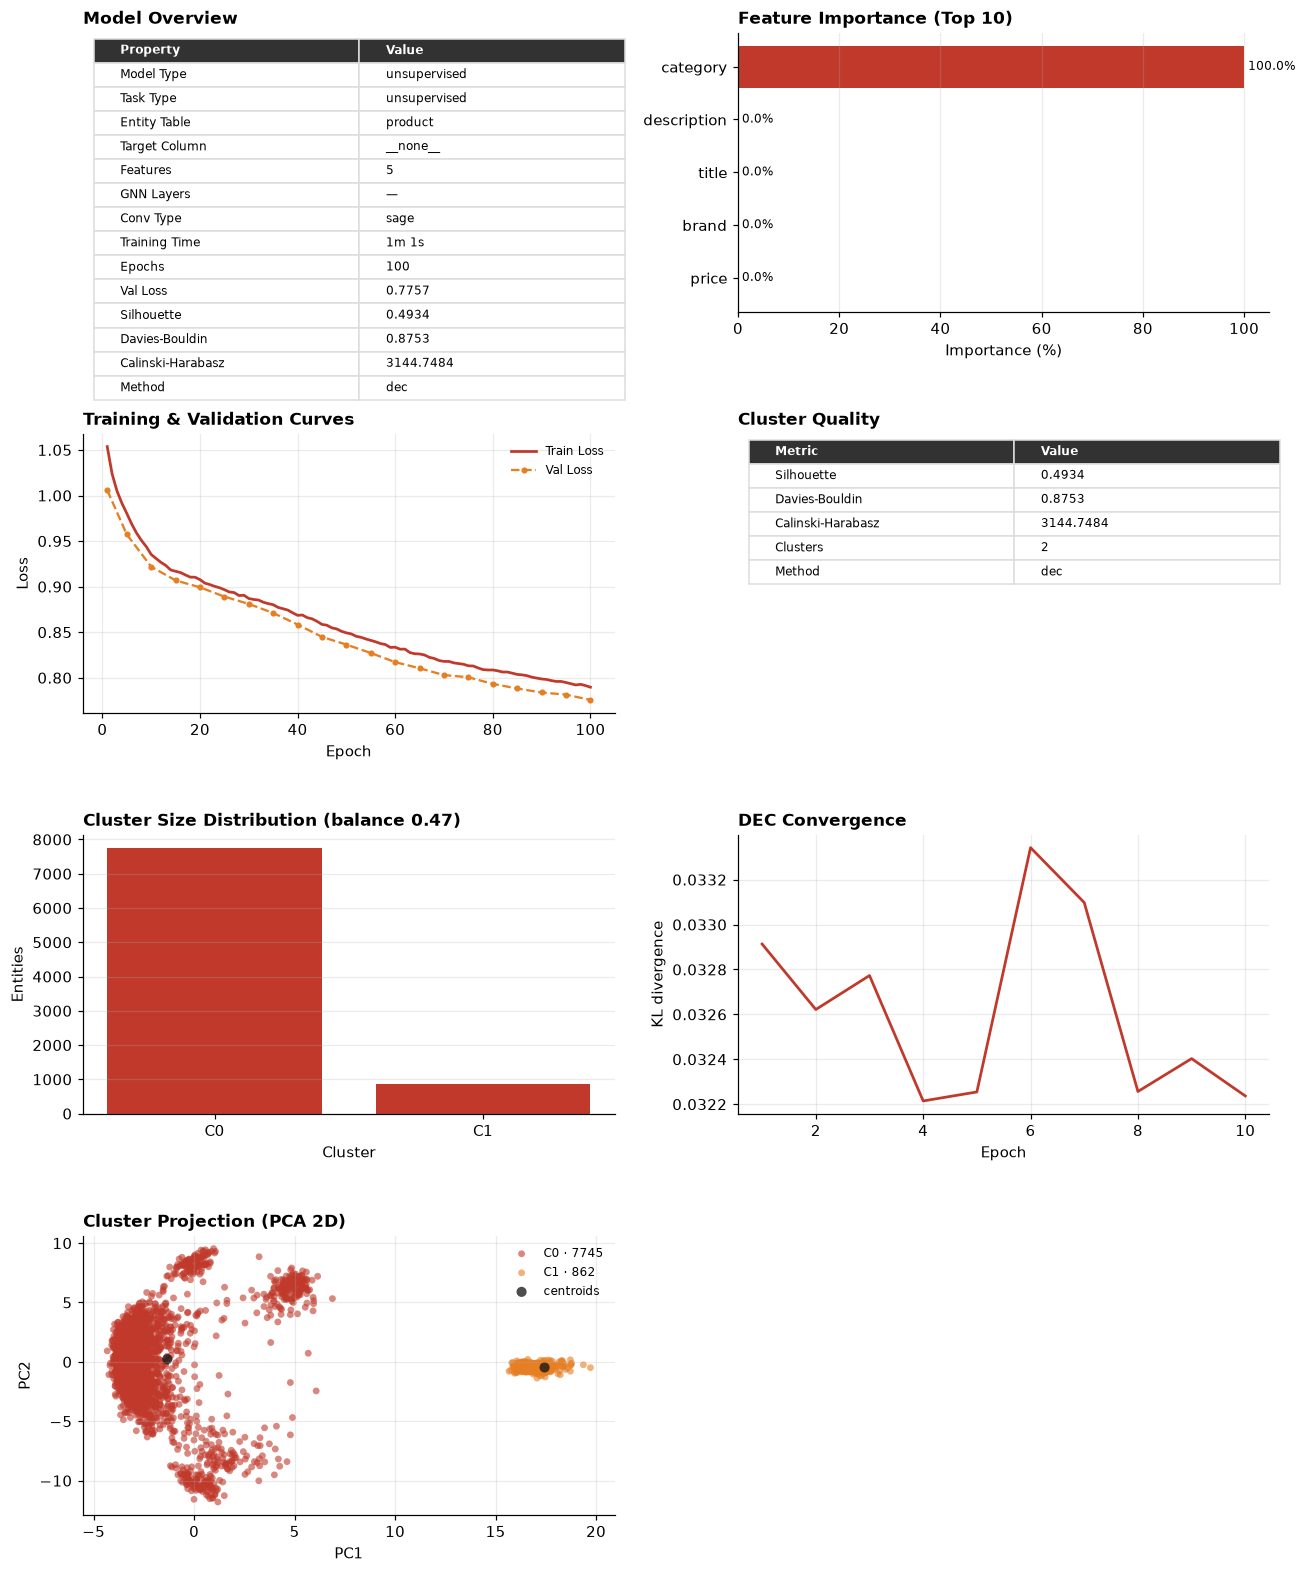

In [4]:
fig(viz.model_dashboard(p, cols=2))

In [5]:
quality = viz.card_table(viz.model_cards(p)["Cluster Quality"])
quality

{'Silhouette': '0.4934',
 'Davies-Bouldin': '0.8753',
 'Calinski-Harabasz': '3144.7484',
 'Clusters': '2',
 'Method': 'dec'}

## Read the segments

Score a sample of products (50 credits each — 40 here) and describe each cluster by its members: titles, median price, how many reviews they attract.

In [6]:
product = p.table("product").to_pandas()
review = p.table("review").to_pandas()
sample = product.sample(40, random_state=7)
ids = sample["product_id"].tolist()
batch = ls.predict.predict_batch(model_id=model["model_id"], entity_ids=ids)
sample = sample.assign(cluster=[pr.get("cluster", pr.get("prediction")) for pr in batch["predictions"]])
sample = sample.merge(review.groupby("product_id")["rating"].agg(reviews="count", mean_rating="mean"), left_on="product_id", right_index=True, how="left")
print(sample.groupby("cluster").agg(products=("product_id", "count"), median_price=("price", "median"), reviews=("reviews", "mean"), mean_rating=("mean_rating", "mean")).round(2))
for cl, grp in sample.groupby("cluster"):
    print(f"\ncluster {cl}:")
    for t in grp["title"].head(4): print("   ", t[:80])

         products  median_price  reviews  mean_rating
cluster                                              
0              37         12.99     1.08         4.40
1               3          7.08     1.00         4.67

cluster 0:
    Reaper (Boston Underworld) (Volume 2)
    Rick Steves Snapshot Hill Towns of Central Italy: Including Siena &amp; Assisi
    Halley's Bible Handbook with the New International Version---Deluxe Edition
    Charlotte's Web (50th Anniversary Retrospective Edition)

cluster 1:
    The Imposter Bride: A Novel
    The Risen: Courage
    Soldier of Rome: Heir to Rebellion: Book Three of The Artorian Chronicles


In [7]:
charged = credits_used(ls) - before
save_metrics(".", {"notebook": "05_product_clustering", "task": "clustering · product (unsupervised)", "model": model.get("model_type"),
                   "project_id": p.id, "model_id": model["model_id"], "training_duration_sec": model.get("training_duration_sec"),
                   "credits_charged_this_run": charged,
                   "headline": {"val_loss": metrics.get("val_loss"), "silhouette": quality.get("Silhouette"), "davies_bouldin": quality.get("Davies-Bouldin"), "clusters": quality.get("Clusters"),
                                "note": "quality numbers come from the Model tab cards"}})

wrote results/metrics.json


PosixPath('results/metrics.json')

## Where to go next

- [06 · Review anomaly detection](../06_review_anomaly/) — the other unsupervised task